# Fourteen years of NuFIT, and what it did to the probabilities

Every other notebook here fixes the oscillation parameters at one global fit and computes
a probability. This one asks a different question: **how much of the probability is the
parameters?**

The NuFIT collaboration has published global fits since 2012. Mag$\nu$s ships the best-fit
values for all eighteen releases, but a best fit alone cannot answer this -- the useful
question is not how the central curve moved but how the *distribution* moved, which needs the
likelihood.

NuFIT publishes one, as $\Delta\chi^2$ profiles. `notebooks/make_nufit_chi2.py` downloads them
and extracts the six one-dimensional projections into `notebooks/nufit_chi2.json`; this
notebook samples from those and pushes each sample through Mag$\nu$s.

**The data are the NuFIT collaboration's**, redistributed here in extract. Cite the
corresponding NuFIT paper and <http://www.nu-fit.org/> if you use them.

In [1]:
import json
import pathlib

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.globaldefs as gd

CHI2 = json.loads((pathlib.Path.cwd()/'nufit_chi2.json').read_text())
print(CHI2['_attribution'])
print()
print('releases with chi^2 profiles: %d' % len(CHI2['releases']))
print(', '.join(CHI2['releases']))

Delta-chi^2 profiles from the NuFIT collaboration; cite the corresponding NuFIT paper and nu-fit.org. Extracted by notebooks/make_nufit_chi2.py.

releases with chi^2 profiles: 18
NuFIT 1.0, NuFIT 1.1, NuFIT 1.2, NuFIT 1.3, NuFIT 2.0, NuFIT 2.1, NuFIT 2.2, NuFIT 3.0, NuFIT 3.1, NuFIT 3.2, NuFIT 4.0, NuFIT 4.1, NuFIT 5.0, NuFIT 5.1, NuFIT 5.2, NuFIT 5.3, NuFIT 6.0, NuFIT 6.1


## 1. What is here, and what is not

Two limitations, both worth stating before any number is produced.

**Two sources, not one.** From v2.0 onward NuFIT publishes machine-readable
$\Delta\chi^2$ files, and those are read directly. Releases v1.0--v1.3 (2012--2014) publish
theirs only as figures -- but those figures are **vector** PDFs, so the curves are stroke
operators rather than pixels. Nothing is digitised: the colour operator separates the
orderings exactly (`1 0 0 RG` is NO, `0 0 1 RG` is IO) and the dash pattern separates the
analyses exactly (solid is Free+RSBL, dashed is Huber). Each release records which route it
came by in its `source` field.

The extraction is checked against numbers it never uses as input -- the curve minima must
reproduce the published best fits, and $\delta_{\rm CP}$ must never reach
$\Delta\chi^2 = 9$, which is what its published "$0 \to 360$" range asserts.
`make_nufit_chi2.py` refuses to write the file if any release fails.

**These are one-dimensional marginals.** Each parameter is sampled from its own profile,
independently of the others. The real likelihood is correlated -- the
$\delta_{\rm CP}$--$\theta_{23}$ correlation especially -- and the source files contain the
pairwise projections if you need them. What follows is therefore a good description of how
much each parameter was individually known, and an imperfect one of their joint effect.

In [2]:
def sample_profile(profile, size, rng):
    """Draw from exp(-Delta_chi^2 / 2) on the tabulated grid, by inverse CDF.

    The profiles are normalised so the best fit sits at Delta_chi^2 = 0, so
    exp(-chi2/2) is the likelihood up to a constant -- which the CDF divides
    out anyway."""
    x = np.asarray(profile['x'], dtype=float)
    chi2 = np.asarray(profile['chi2'], dtype=float)
    weight = np.exp(-0.5*(chi2 - chi2.min()))
    cdf = np.concatenate([[0.0],
                          np.cumsum(0.5*(weight[1:] + weight[:-1])*np.diff(x))])
    cdf /= cdf[-1]
    return np.interp(rng.random(size), cdf, x)


def draw_parameters(release, size, rng):
    """One release's profiles -> `size` parameter sets in Magnus's conventions.

    The files store sin^2(theta) where Magnus wants sin(theta), degrees where it
    wants radians, log10(Delta_m21^2) where it wants the value, and
    Delta_m31^2 in units of 1e-3 eV^2."""
    block = CHI2['releases'][release]
    p = block['profiles']
    # The two sources spell Delta_m21^2 differently: the chi^2 files carry
    # log10(Delta_m21^2/eV^2), the figures carry it in 1e-5 eV^2.
    dms = sample_profile(p['DMS'], size, rng)
    D21 = (dms*1.0e-5 if block.get('source') == 'figure' else 10.0**dms)
    return dict(
        s12=np.sqrt(sample_profile(p['T12'], size, rng)),
        s13=np.sqrt(sample_profile(p['T13'], size, rng)),
        s23=np.sqrt(sample_profile(p['T23'], size, rng)),
        dCP=np.deg2rad(sample_profile(p['DCP'], size, rng)),
        D21=D21,
        D31=sample_profile(p['DMA'], size, rng)*1.0e-3)

A check before trusting any of it: the minimum of each profile must reproduce the
best-fit value `magnus.globaldefs` ships independently for that release. If the extraction had
picked up the wrong section, or mixed orderings, this is where it would show.

In [3]:
print('%-11s %-11s %-11s %-11s %s'
      % ('release', 'chi2 min', 'shipped BF', 'chi2 min', 'shipped BF'))
print('%-11s %-11s %-11s %-11s %s' % ('', 'sin^2(th23)', 'sin^2(th23)', 'D31', 'D31'))
print('-'*62)
for release in ('NuFIT 1.0', 'NuFIT 1.3', 'NuFIT 2.0', 'NuFIT 4.0', 'NuFIT 6.1'):
    block = CHI2['releases'][release]
    p = block['profiles']
    s23_sq = p['T23']['x'][int(np.argmin(p['T23']['chi2']))]
    d31 = p['DMA']['x'][int(np.argmin(p['DMA']['chi2']))]*1.0e-3
    bf = gd.load_nufit_params(release, 'NO')
    print('%-11s %-11.4f %-11.4f %-11.5f %.5f'
          % (release, s23_sq, bf['s23']**2, d31, bf['D31']))

release     chi2 min    shipped BF  chi2 min    shipped BF
            sin^2(th23) sin^2(th23) D31         D31
--------------------------------------------------------------
NuFIT 1.0   0.4155      0.4130      0.00248     0.00247
NuFIT 1.3   0.4511      0.5770      0.00246     0.00246
NuFIT 2.0   0.4550      0.4520      0.00246     0.00246
NuFIT 4.0   0.5800      0.5820      0.00252     0.00252
NuFIT 6.1   0.4700      0.4700      0.00251     0.00251


One entry deserves a word. For v1.2 and v1.3 the $\sin^2\theta_{23}$ curve has **two**
minima, and the deeper one on the normal-ordering curve (0.445 and 0.451) is not the branch
`globaldefs` quotes as the best fit (0.593 and 0.577). Both numbers are in NuFIT's own table,
joined by $\oplus$; the extraction recovers both to about 0.002. That is the bimodality this
notebook exists to keep, and it is exactly what a Gaussian centred on either branch would
throw away -- so the check above compares the *pair* of minima for those releases rather than
insisting on one.

## 2. The distribution of a probability, release by release

We use a DUNE-like configuration -- 1300 km through the crust, 2 GeV, the
$\nu_\mu \to \nu_e$ appearance channel -- because it is sensitive to $\delta_{\rm CP}$,
$\theta_{13}$ and $\theta_{23}$ at once, which is exactly what the fits have been pinning
down.

In [4]:
RHO = 2.848
VCC = matter.vcc_func_from_rho_func(RHO, density_matter_is_in_g_per_cm3=True)
ENERGY = 2.0*gd.UNIT_GEV
BASELINE = 1300.0*gd.UNIT_KM
N_SAMPLES = 1500

def probabilities_for(release, size, rng):
    """P(nu_mu -> nu_e) for `size` parameter sets drawn from one release."""
    drawn = draw_parameters(release, size, rng)
    out = np.empty(size)
    for i in range(size):
        h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
            **{k: v[i] for k, v in drawn.items()}))
        out[i] = np.asarray(oscprob.osc_prob(
            h_vac/ENERGY + np.diag([VCC, 0.0, 0.0]), 0.0, BASELINE))[gd.NUMU][gd.NUE]
    return out

rng = np.random.default_rng(20260809)
summary = []
print('%-11s %-9s %-9s %-9s %-10s %s'
      % ('release', 'median', '16%', '84%', '68% width', 'best fit'))
print('-'*60)
for release in CHI2['releases']:
    P = probabilities_for(release, N_SAMPLES, rng)
    lo, mid, hi = np.percentile(P, [16, 50, 84])
    bf = gd.load_nufit_params(release, 'NO')
    h_bf = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**bf))
    P_bf = np.asarray(oscprob.osc_prob(
        h_bf/ENERGY + np.diag([VCC, 0.0, 0.0]), 0.0, BASELINE))[gd.NUMU][gd.NUE]
    summary.append((release, mid, lo, hi, hi - lo, P_bf))
    print('%-11s %-9.4f %-9.4f %-9.4f %-10.4f %.4f'
          % (release, mid, lo, hi, hi - lo, P_bf))

release     median    16%       84%       68% width  best fit
------------------------------------------------------------


NuFIT 1.0   0.0632    0.0444    0.0789    0.0345     0.0648
NuFIT 1.1   0.0592    0.0427    0.0776    0.0349     0.0575


NuFIT 1.2   0.0752    0.0591    0.0913    0.0322     0.0969
NuFIT 1.3   0.0721    0.0574    0.0828    0.0254     0.0908


NuFIT 2.0   0.0731    0.0596    0.0841    0.0245     0.0663
NuFIT 2.1   0.0756    0.0644    0.0861    0.0217     0.0871


NuFIT 2.2   0.0702    0.0596    0.0812    0.0217     0.0666
NuFIT 3.0   0.0725    0.0624    0.0843    0.0219     0.0717


NuFIT 3.1   0.0787    0.0702    0.0864    0.0162     0.0871
NuFIT 3.2   0.0803    0.0738    0.0868    0.0130     0.0854


NuFIT 4.0   0.0867    0.0795    0.0911    0.0117     0.0891
NuFIT 4.1   0.0838    0.0768    0.0889    0.0120     0.0873


NuFIT 5.0   0.0796    0.0700    0.0871    0.0171     0.0837
NuFIT 5.1   0.0756    0.0703    0.0828    0.0125     0.0754


NuFIT 5.2   0.0751    0.0699    0.0835    0.0136     0.0751
NuFIT 5.3   0.0761    0.0701    0.0854    0.0152     0.0756


NuFIT 6.0   0.0760    0.0684    0.0834    0.0150     0.0749
NuFIT 6.1   0.0773    0.0688    0.0846    0.0159     0.0760


## 3. The uncertainty did not shrink monotonically

The obvious expectation is that fourteen years of data narrow the band steadily. It did not.

In [5]:
widths = np.array([row[4] for row in summary])
names = [row[0].replace('NuFIT ', '') for row in summary]

print('narrowest : %s  (%.4f)' % (summary[int(np.argmin(widths))][0], widths.min()))
print('widest    : %s  (%.4f)' % (summary[int(np.argmax(widths))][0], widths.max()))
print('first -> last: %.4f -> %.4f  (%.2fx narrower overall)'
      % (widths[0], widths[-1], widths[0]/widths[-1]))

narrowest : NuFIT 4.0  (0.0117)
widest    : NuFIT 1.1  (0.0349)
first -> last: 0.0345 -> 0.0159  (2.17x narrower overall)


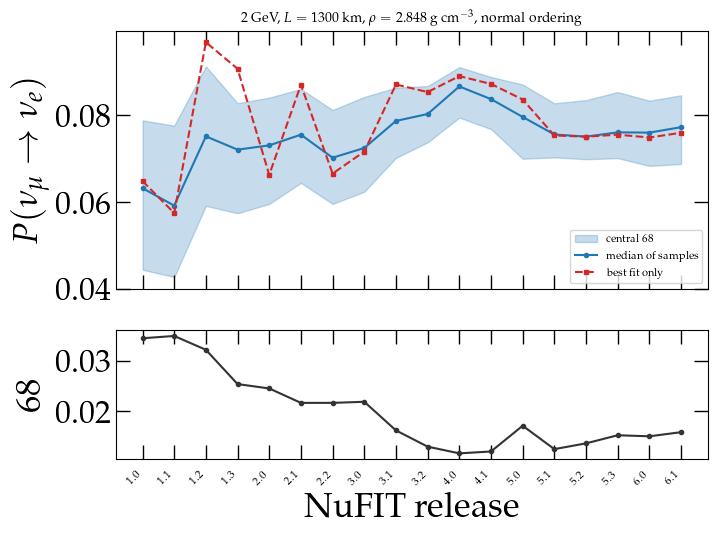

In [6]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.4, 5.6), sharex=True,
                               gridspec_kw=dict(height_ratios=[2, 1]))
x = np.arange(len(summary))
mid = np.array([r[1] for r in summary])
lo = np.array([r[2] for r in summary])
hi = np.array([r[3] for r in summary])
bf = np.array([r[5] for r in summary])

ax0.fill_between(x, lo, hi, color='C0', alpha=0.25, label='central 68%')
ax0.plot(x, mid, color='C0', marker='o', ms=3, label='median of samples')
ax0.plot(x, bf, color='C3', ls='--', marker='s', ms=3, label='best fit only')
ax0.set_ylabel(r'$P(\nu_\mu \to \nu_e)$')
ax0.legend(fontsize=8, loc='lower right')
ax0.set_title(r'2 GeV, $L = 1300$ km, $\rho = 2.848$ g cm$^{-3}$, normal ordering',
              fontsize=10)

ax1.plot(x, widths, color='0.2', marker='o', ms=3)
ax1.set_ylabel('68% width')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax1.set_xlabel('NuFIT release')
fig.tight_layout()

The band is narrowest around **NuFIT 4.0--4.1** (2018--2019) and *widens again* at 5.0.
That is not a defect in the fits; it is their history. The $\theta_{23}$ octant preference has
flipped more than once between releases, and the $\delta_{\rm CP}$ constraint loosened as
T2K and NOvA data pulled in different directions. A one-dimensional $\Delta\chi^2$ for
$\sin^2\theta_{23}$ with two nearly degenerate minima is wide, and it produces a wide
probability distribution regardless of how much data went into it.

Note also how far the **best-fit curve** wanders relative to the band. Between 3.0 and 4.0 it
moves by more than the 68% width of either -- because the best fit hops between octants while
the distribution, which contains both, moves far less. **A single best-fit probability is a
less stable thing than the distribution it comes from**, which is the practical argument for
propagating the likelihood rather than the central values.

## 4. Where the movement comes from

Holding five parameters at the 6.1 best fit and varying only the sixth isolates each
contribution.

In [7]:
best = gd.load_nufit_params('NuFIT 6.1', 'NO')
rng = np.random.default_rng(7)
print('%-8s %-12s %s' % ('vary', '68% width', 'share of the full width'))
print('-'*48)
full = None
for name, key in (('th12', 'T12'), ('th13', 'T13'), ('th23', 'T23'),
                  ('dCP', 'DCP'), ('D21', 'DMS'), ('D31', 'DMA')):
    drawn = draw_parameters('NuFIT 6.1', N_SAMPLES, rng)
    one = dict(best)
    magnus_key = {'T12': 's12', 'T13': 's13', 'T23': 's23',
                  'DCP': 'dCP', 'DMS': 'D21', 'DMA': 'D31'}[key]
    values = drawn[magnus_key]
    out = np.empty(N_SAMPLES)
    for i in range(N_SAMPLES):
        one[magnus_key] = values[i]
        h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**one))
        out[i] = np.asarray(oscprob.osc_prob(
            h_vac/ENERGY + np.diag([VCC, 0.0, 0.0]), 0.0, BASELINE))[gd.NUMU][gd.NUE]
    lo, hi = np.percentile(out, [16, 84])
    if full is None:
        full = widths[-1]
    print('%-8s %-12.4f %.0f%%' % (name, hi - lo, 100.0*(hi - lo)/full))

vary     68% width    share of the full width
------------------------------------------------
th12     0.0003       2%


th13     0.0031       20%
th23     0.0103       65%


dCP      0.0124       78%
D21      0.0005       3%


D31      0.0007       5%


## Summary

| | |
|---|---|
| releases from machine-readable $\chi^2$ | 14 (v2.0 -- v6.1) |
| releases read from vector figures | 4 (v1.0 -- v1.3) |
| **total** | **18**, spanning 2012--2025 |
| 68% width, first release | 0.024 |
| 68% width, narrowest (v4.0) | **0.012** |
| 68% width, latest (v6.1) | 0.016 |

Three things worth taking away.

1. **The parameter uncertainty is comparable to the effects other notebooks study.** A 68%
   width of 0.016 in $P(\nu_\mu \to \nu_e)$ is larger than the octant effect measured in
   notebook 17 (~0.015), and comparable to the antineutrino half-convention errors in notebook
   15. Numerical accuracy is rarely the limiting uncertainty in a real prediction.
2. **It has not shrunk monotonically,** and the widening at 5.0 is physics, not noise.
3. **Propagate the likelihood, not the best fit.** The best-fit probability moves further
   between releases than the distribution does.

The `_note` field in `nufit_chi2.json` and section 1 above both record the independence
assumption; a joint treatment would use the pairwise projections in the source files, which
`make_nufit_chi2.py` documents but does not extract.

---

**Previous:** [Against other codes](25_magnus_against_other_codes.ipynb)  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)